In [263]:
import pandas as pd
import numpy as np
from imagecodecs import NoneError
from scipy.stats import hmean
import matplotlib.pyplot as plt
import os

In [264]:
plt.style.use("default")

In [265]:
'''Lire les ability profiles, regrouper ceux du nature et les plus récents'''
nature_profiles_df = pd.read_csv("ability_profiles/ability_profiles_MaxAuxDiff=0_DupThresh=100.csv", index_col=0)
additional_profiles_df = pd.read_csv('data/additional_results_16June2026.csv', index_col=0)
ability_profiles_df = pd.concat([nature_profiles_df, additional_profiles_df], axis=0)

In [266]:
'''Collapser les ability profiles sur les groupes de dimensions du human scales'''
#On exploite la nomenclature des auteurs, dans laquelle chaque nom de groupe est constitué de deux lettres majuscules qui sont les deux premières lettres des dimensions qui le constituent
#Une exception à traiter à part : SNs
dimension_groups = list(set([name[:2] for name in ability_profiles_df.columns]))
dimensions = list(ability_profiles_df.columns)
#groupping_dict = {name : name[:2] for name in dimensions}
for dimension_group in dimension_groups:
    components = [dimension for dimension in dimensions if dimension[:2] == dimension_group]
    if len(components) >= 2:
        ability_profiles_df[dimension_group] = ability_profiles_df[components].apply(hmean, axis=1)
ability_profiles_df['SN'] = ability_profiles_df['SNs'].copy()
reduced_profiles_columns = list(dimension_groups)
reduced_profiles_df = ability_profiles_df[reduced_profiles_columns].copy()

In [267]:
'''Changement d'échelle avec les coefficients fournis par le human scales'''
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv")
rescaled_profiles_df = reduced_profiles_df.copy()
dimension_groups = [dimension_group for dimension_group in dimension_groups if
                    dimension_group in rescaling_coefficients_df.columns]
for dimension_group in dimension_groups:
    rescaled_profiles_df[dimension_group] = rescaled_profiles_df[dimension_group].apply(
        lambda x: rescaling_coefficients_df[dimension_group].iloc[0] * x +
                  rescaling_coefficients_df[dimension_group].iloc[1] - 0.5)
rescaled_profiles_df = rescaled_profiles_df[dimension_groups]

In [268]:
release_dates_df = pd.read_csv("data/release_dates.csv", index_col=0)
release_dates_df = release_dates_df[['Date de sortie']]
release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])
rescaled_profiles_df['Date'] = release_dates_df['Date de sortie']

C:\Users\Michel\AppData\Local\Temp\ipykernel_22036\2204164536.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])


In [269]:
def frontier_indices(xs, ys): #Vérifier le traitement des cas d'égalité. Il faudrait idéalement contrôler si plusieurs modèles sortis le même jour et dépassant ceux qui les précèdent sont tous frontière, ou seulement le meilleur d'entre eux. La version actuelle du code ne me semble pas donner de garantie à ce sujet.
    assert len(xs) == len(ys)
    sorted_order = np.argsort(xs)
    current_max = -np.inf
    front_original_indices = []
    for idx in sorted_order:
        if ys[idx] > current_max:
            current_max = ys[idx]
            front_original_indices.append(idx)
    return front_original_indices

In [270]:
corporations = {'Babbage-002' : 'OpenAI',
                'Davinci-002' : 'OpenAI',
                'GPT-3.5-Turbo' : 'OpenAI',
                'GPT-4o' : 'OpenAI',
                'OpenAI o1-mini' : 'OpenAI',
                'OpenAI o1' : 'OpenAI',
                'LLaMA-3.2-1B-Instruct' : 'Meta',
                'LLaMA-3.2-3B-Instruct' : 'Meta',
                'LLaMA-3.2-11B-Instruct' : 'Meta',
                'LLaMA-3.2-90B-Instruct' : 'Meta',
                'LLaMA-3.1-405B-Instruct' : 'Meta',
                'DK-R1-Dist-Qwen-1.5B' : 'Qwen',
                'DK-R1-Dist-Qwen-7B' : 'Qwen',
                'DK-R1-Dist-Qwen-14B' : 'Qwen',
                'DK-R1-Dist-Qwen-32B' : 'Qwen',
                'Gemini-2.5-Flash' : 'Google',
                'Gemini-3.1-Flash' : 'Google',
                'Gemini-3.1-Pro' : 'Google',
                'LLaMA-4-17B-128E' : 'Meta',
                'GPT-5.2-Chat' : 'OpenAI',
                'OpenAI o3-mini' : 'OpenAI'}


In [271]:
corpo_color_map = {'OpenAI' : 'r',
                   'Meta' : 'b',
                   'Qwen' : 'g',
                   'Google' : 'purple'}

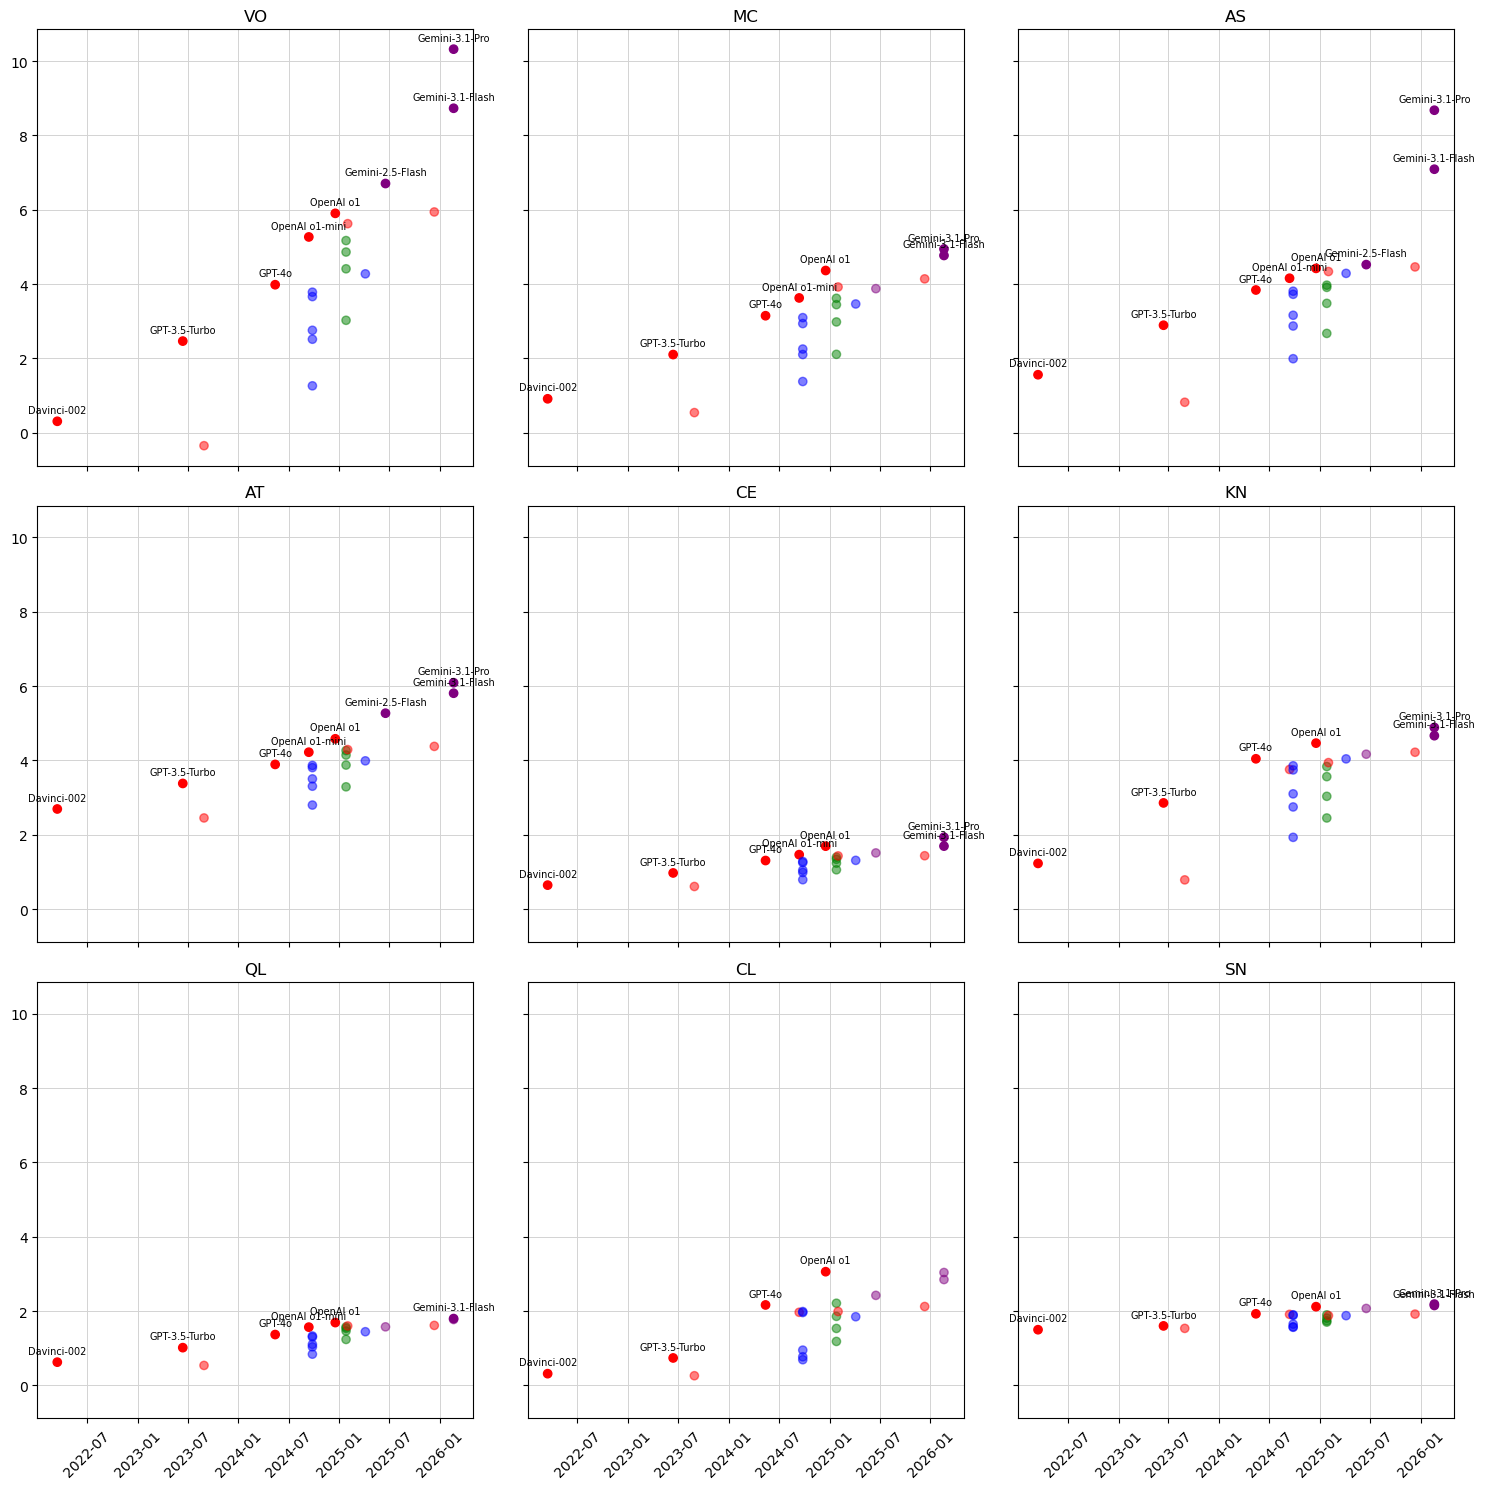

In [272]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
demand_groups = list(rescaled_profiles_df.columns)
demand_groups.remove('Date')
release_dates = rescaled_profiles_df['Date'].values
model_names = list(rescaled_profiles_df.index)
xs = release_dates
colors = [corpo_color_map[corporations[x]]  for x in model_names]

for i in range(3):
    for j in range(3):
        ax = axs[i][j]
        ys = rescaled_profiles_df[demand_groups[3*i+j]].values
        front = set(frontier_indices(xs, ys))
        alphas = []
        for k in range(len(xs)):
            if k in front:
                alphas.append(1)
            else : alphas.append(0.5)

        ax.scatter(xs, ys, zorder=3, c=colors, alpha=alphas)

        # Labels frontière
        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        ax.set_title(demand_groups[3*i+j])

        # Grille gris clair
        ax.grid(True, color='lightgrey', linewidth=0.7, zorder=0)
        ax.set_axisbelow(True)

        # Rotation xticks
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()